In [72]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

from sklearn.datasets import load_iris

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy

# =====================================


### What is diference between fit and partial_fit ? When to use fit or partial_fit ?

Fit Method:

The fit method is used to train a model on the entire dataset at once. It takes the entire dataset as input and updates the model's parameters to minimize the loss function.

##### **Partial Fit Method:**

The partial_fit method is used to train a model on a subset of the data at a time. 

##### **When to use Partial fit:** 

It is useful for online learning, incremental learning, or when the dataset is too large to fit into memory.


### what difference betwwen transform and fit transform ?

#### When to use fit_transform() vs. transform():

fit_transform():
Primarily used on the training data to learn the transformation parameters and apply them simultaneously.
transform():
Used on both the training and testing data (after fit_transform() or fit() has been applied to the training data) to apply the learned transformation. 

1. scaler.fit_transform(X_train) learns the mean and standard deviation from X_train and then scales it. 

2. scaler.transform(X_test) applies the same scaling parameters learned from the training data to X_test. 

#### Why use transform() after fit_transform()?

Using transform() on the testing data ensures that the testing data is transformed using the same parameters learned from the training data. This prevents data leakage from the testing set to the training set, which can lead to overfitting. 

### What is Early Stopping?
Early stopping is a technique used in machine learning to prevent overfitting by stopping the training process when the model's performance on the validation set starts to degrade.
This is typically done by tracking a performance metric such as accuracy, loss, or F1-score.

Early stopping works by:

1. Splitting the data: The data is split into training and validation sets.
2. Training the model: The model is trained on the training set.
3. Monitoring performance: The model's performance is monitored on the validation set during training.
4. Stopping criterion: The training process is stopped when the model's performance on the validation set starts to degrade.

###### Types of Early Stopping:

There are two main types of early stopping:

1. Fixed early stopping: The training process is stopped after a fixed number of epochs or iterations.
2. Adaptive early stopping: The training process is stopped when the model's performance on the validation set starts to degrade.

##### Advantages of Early Stopping
1. Prevents overfitting
2. Saves computational resources
3. Improves generalization

##### Disadvantages of Early Stopping
1. May stop too early
2. May not work well with noisy data



In [144]:
# Create Data Set in X y formatt
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below


In [145]:
preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())


In [146]:


X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid) #  applies the same scaling parameters 
                                                #  learned from the training data to X_test
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)


In [149]:
for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train) # why partial fit, we are using incremental learning
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    # RMS error b/w Preditect test set and Actual Test Set
    val_errors.append(val_error)
    # RMS error b/w Predicted training set and Actual Training Set
    train_errors.append(train_error)

print('Total Run Epoch: ', epoch)
# index pos & min rms value error from test set   
print('index pos: ', np.argmin(val_errors), ' rmas val error: ',val_errors[np.argmin(val_errors)])

# index pos & min rms value error from training set
print('index pos: ', np.argmin(train_errors), ' rmas val error: ',train_errors[np.argmin(val_errors)])

Total Run Epoch:  499
index pos:  249  rmas val error:  1.4099344710854789
index pos:  999  rmas val error:  0.9003558098557815


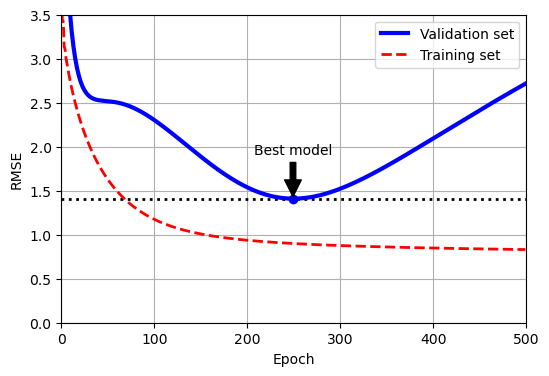

In [148]:
min_val_error_idx = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(min_val_error_idx, best_valid_rmse),
             xytext=(min_val_error_idx, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(min_val_error_idx, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")

plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
#save_fig("early_stopping_plot")
plt.show()

### Use Same code for statemodels OLS instade of SGD


In [ ]:
for epoch in range(n_epochs):
    model = sm.OLS(X_train_prep, y_train) # why partial fit, we are using incremental learning
    res = model.fit()
    y_valid_predict = res.predict()(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    # RMS error b/w Preditect test set and Actual Test Set
    val_errors.append(val_error)
    # RMS error b/w Predicted training set and Actual Training Set
    train_errors.append(train_error)

print('Total Run Epoch: ', epoch)
# index pos & min rms value error from test set   
print('index pos: ', np.argmin(val_errors), ' rmas val error: ',val_errors[np.argmin(val_errors)])

# index pos & min rms value error from training set
print('index pos: ', np.argmin(train_errors), ' rmas val error: ',train_errors[np.argmin(val_errors)])